🧬 01_Gene_to_Protein Notebook: From APOE Gene to Protein

🧠 APOE apolipoprotein E [ Homo sapiens (human) ] 


### ⭐ 1. Introduction

Question 
- What is the APOE gene, where is it located, and what protein does it encode?
  


APOE (Apolipoprotein E) is involved in lipid transport and is strongly associated with Alzheimer's disease.

Steps in this notebook:
1. Get gene information manually from NCBI
2. Download FASTA sequence
3. Analyze sequence (length, GC%, Nucleotides Frequency)
4. Transcribe (DNA to RNA) and translate (RNA to Protein)
5. Analyze protein properties


---

### ⭐ 2. Import Required Libraries

In [2]:
import pandas as pd
import matplotlib as plt

from Bio import Entrez                      # Entrez can actually handles messages (communication) between our computer and the NCBI database.

from Bio import SeqIO                       # SeqIO reads and writes biological sequence file formats like FASTA.

from Bio.SeqUtils import ProtParam          # ProtParam analyzes protein properties (like MW, pI, instability)
 
Entrez.email = "sahelsepehri99@gmail.com"   # We sould tell NCBI who we are so we won't get blocked.


---


### ⭐ 3. Biological and Database Exploration of APOE

Retrieving APOE gene from NCBI


[NCBI - APOE Page](https://www.ncbi.nlm.nih.gov/gene/?term=APOE)


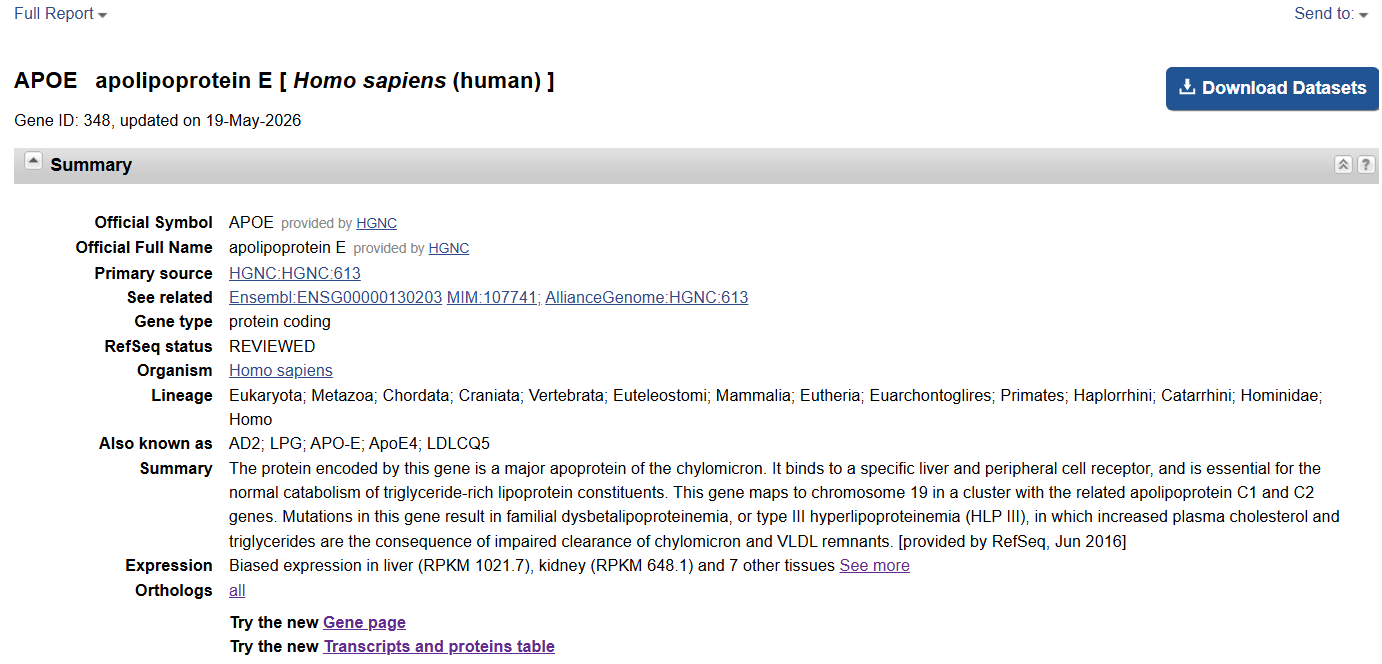

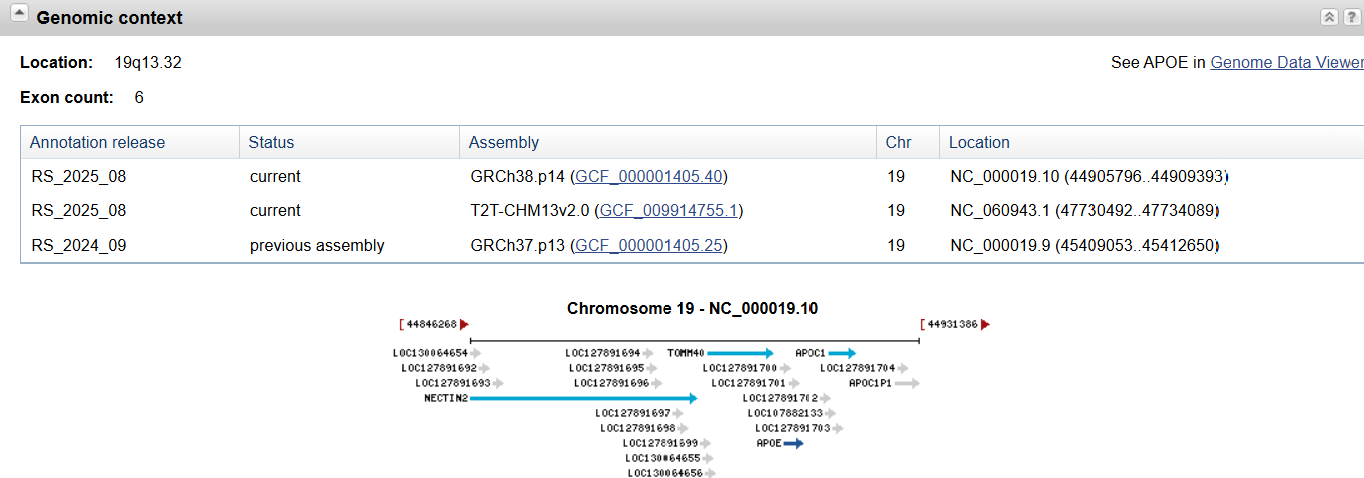

In [37]:
apoe_human_info = {
    "Gene Symbol" : "APOE",
    " Accession Number" :"NC_000019.10",
    "Official Full Name" : "apolipoprotein E",
    "NCBI Gene ID" : "348",
    "Gene type" : "protein coding",
    "Ensembl ID" : "ENSG00000130203",
    "HGNC ID" : "HGNC:613",
    "Other Names" : "AD2, LPG, APO-E, ApoE4, LDLCQ5",
    "Organism" : "Homo sapiens",
    "Protein Isoforms" : "5",
    "Transcripts Counts" : "5",
    "Chromosome": "19",
    "Location": "19q13.32",
    "Exon count": "6",
    "Intron count" : "5"  #Exon - 1
}

In [38]:
df = pd.DataFrame(list(apoe_human_info.items()), columns= ["Identifier Type", "Value"])

df.style

,Identifier Type,Value
0,Gene Symbol,APOE
1,Accession Number,NC_000019.10
2,Official Full Name,apolipoprotein E
3,NCBI Gene ID,348
4,Gene type,protein coding
5,Ensembl ID,ENSG00000130203
6,HGNC ID,HGNC:613
7,Other Names,"AD2, LPG, APO-E, ApoE4, LDLCQ5"
8,Organism,Homo sapiens
9,Protein Isoforms,5


---

### ⭐ 4. Reproducing Manual Findings Programmically

4.1 Gene ID

In [5]:
search_handle = Entrez.esearch(
    db= "gene",
    term = "APOE[Gene] AND Homo sapiens [Organism]"
)

search_record = Entrez.read(search_handle)
gene_id = search_record ["IdList"][0]
print(f" APOE Gene ID: {gene_id}")

 APOE Gene ID: 348


---
4.2 Gene Summary

In [6]:
handle = Entrez.esummary(
    db="gene",
    id=gene_id,
    retmode="xml"
)

summary = Entrez.read(handle)

doc = summary["DocumentSummarySet"]["DocumentSummary"][0]


data = {
    "Gene Name": doc["Name"],
    "Description": doc["Description"],
    "Chromosome": doc["Chromosome"],
    "Map Location": doc["MapLocation"],
    "Aliases": doc["OtherAliases"]
}

df = pd.DataFrame([data])
df



,Gene Name,Description,Chromosome,Map Location,Aliases
0,APOE,apolipoprotein E,19,19q13.32,"AD2, APO-E, ApoE4, LDLCQ5, LPG"


---

### mRNA
>NM_000041.4

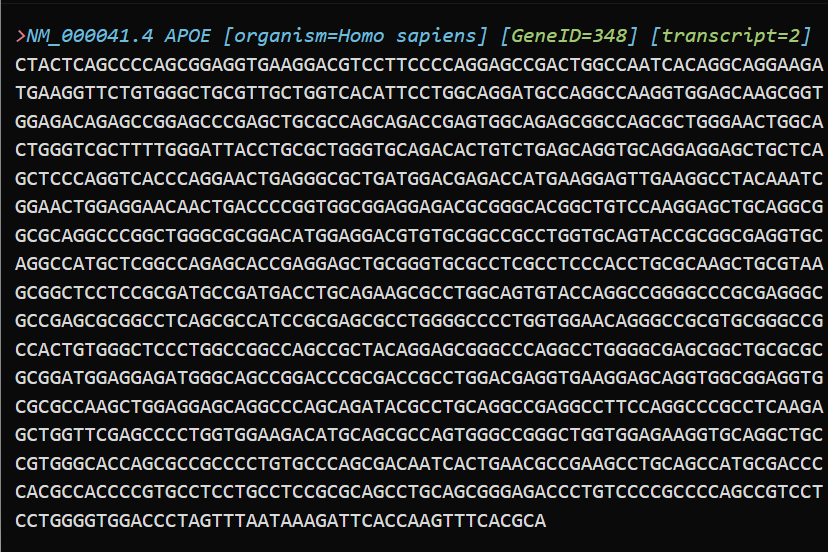

### ⭐ Programmatic mRNA Retrieval with Biopython

Instead of manual exploration, we can fetch the mRNA sequence directly from NCBI using Biopython's Entrez.efetch.

In [7]:
# Fetch means " to go and get something or someone and bring them back"
# We ask NCBI to fetch a specific mRNA ID and save the connection handle
# id="NM_000041.4" -> id number for APOE main mRNA
# rettype="fasta" -> brings a protein in FASTA format. 
# retmode = "text" -> returns a simple text format (FASTA) instead of XML 

handle = Entrez.efetch(
    db="nucleotide",
    id="NM_000041.4",
    rettype="fasta",
    retmode="text"
)

mrna_record = SeqIO.read(handle, "fasta")

# Pull the text data out of the connection handle stream

print(mrna_record.description)
print("\nFirst 100 characters of FASTA:")
print(mrna_record.seq[:100])

print("Sequence length:", len(mrna_record.seq))


# Save to file
SeqIO.write(mrna_record, "APOE_mRNA.fasta", "fasta")
print("\nSaved as APOE_mRNA.fasta")

NM_000041.4 Homo sapiens apolipoprotein E (APOE), transcript variant 2, mRNA

First 100 characters of FASTA:
CTACTCAGCCCCAGCGGAGGTGAAGGACGTCCTTCCCCAGGAGCCGACTGGCCAATCACAGGCAGGAAGATGAAGGTTCTGTGGGCTGCGTTGCTGGTCA
Sequence length: 1166

Saved as APOE_mRNA.fasta


---
### Nucleotide Composition and GC Content
The GC content is an important feature of DNA/RNA sequences, affecting stability and gene regulation.

In [8]:
# Calculate nucleotide counts and GC content

c_count = mrna_record.seq.count("C")  # Count Cytosine bases
g_count = mrna_record.seq.count("G")  # Count Guanine bases
a_count = mrna_record.seq.count("A")  # Count Adenine bases
t_count = mrna_record.seq.count("T")  # Count Thymine bases (in mRNA it's U, but here T is used)

# Calculate total sequence length
total = len(mrna_record.seq)

# Calculate GC content as percentage: (G + C) / total * 100
# Higher GC content means more stable RNA/DNA structure
gc_content = (g_count + c_count) / total * 100

# Print results
print(f"Total length: {total} nucleotides")
print(f"\nNucleotide counts:")
print(f"  A: {a_count} ({a_count/total*100:.2f}%)")  # Adenine percentage
print(f"  C: {c_count} ({c_count/total*100:.2f}%)")  # Cytosine percentage
print(f"  G: {g_count} ({g_count/total*100:.2f}%)")  # Guanine percentage
print(f"  T: {t_count} ({t_count/total*100:.2f}%)")  # Thymine percentage

print(f"\n GC Content: {gc_content:.2f}%")  # Final GC percentage

Total length: 1166 nucleotides

Nucleotide counts:
  A: 211 (18.10%)
  C: 373 (31.99%)
  G: 432 (37.05%)
  T: 150 (12.86%)

 GC Content: 69.04%


---

### Protein 
>NP_000032.1
- NP_000032.1 is the RefSeq identifier for APOE isoform b precursor.
- This is the primary protein product of transcript variant 2 (NM_000041.4).

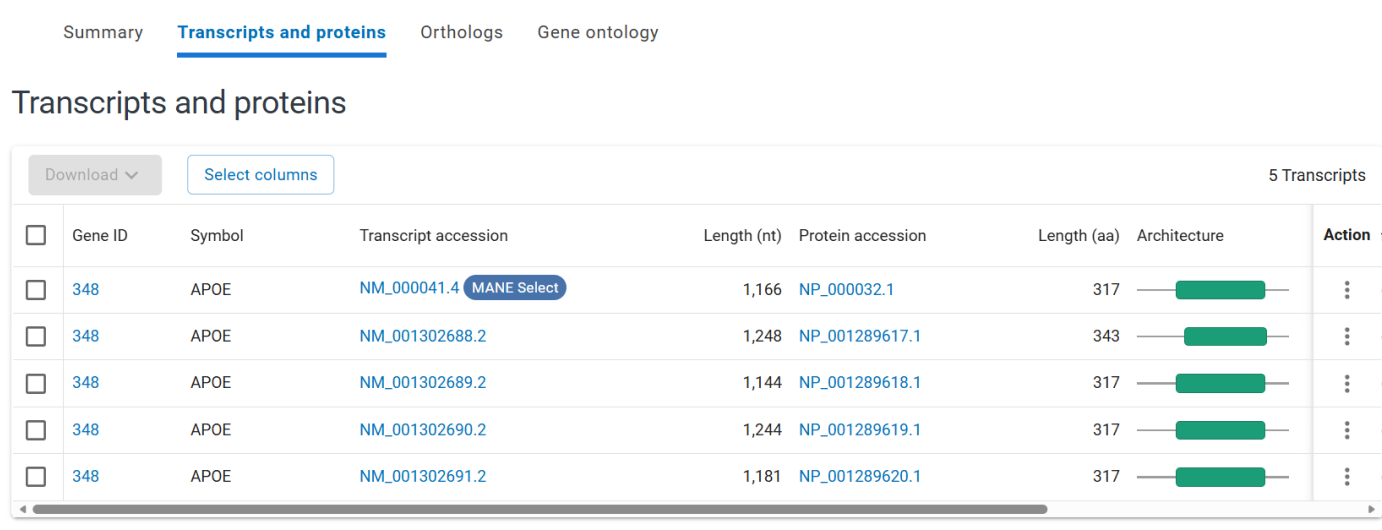

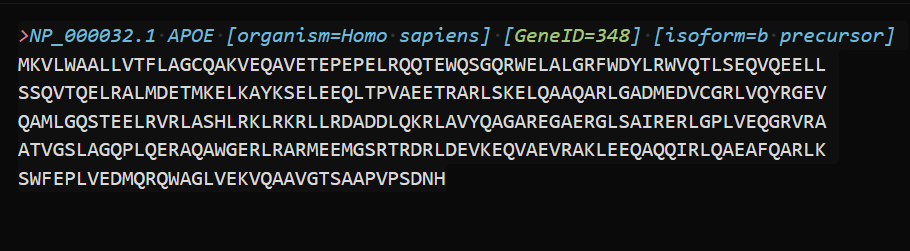

 ### APOE protein properties

In [9]:
apoe_protein_info = {
    "Protein title" : "apolipoprotein E isoform b precursor",
    "Protein comment" : "isoform b precursor is encoded by transcript variant 2",
    "Protein Refseq" : "NP_000032.1",
    "Protein length" : "317 aa",
    "Organism" : "Homo sapiens",
    "Protein Isoforms" : "5",
    "Protein Function" : ""
}

In [10]:
df = pd.DataFrame(list(apoe_protein_info.items()), columns= ["Identifier Type", "Value"])

df.style

,Identifier Type,Value
0,Protein title,apolipoprotein E isoform b precursor
1,Protein comment,isoform b precursor is encoded by transcript variant 2
2,Protein Refseq,NP_000032.1
3,Protein length,317 aa
4,Organism,Homo sapiens
5,Protein Isoforms,5
6,Protein Function,


### ⭐ Retrieving APOE Protein Sequence Programmatically (Biopython)

Like mRNA, we can also fetch the protein sequence directly from NCBI using Biopython's Entrez.efetch.

In [11]:
handle = Entrez.efetch(             # Fetch APOE protein sequence from NCBI using its RefSeq ID
    db="protein",
    id="NP_000032.1",
    rettype="fasta",
    retmode="text"
    )

protein_record = SeqIO.read(handle, "fasta")    # Read the sequence and close connection
handle.close()

# Display sequence info
print(protein_record.description)
print("\nFirst 100 characters of FASTA:")
print(protein_record.seq[:100])
print("Protein length:", len(protein_record.seq), "a.a")


# Save to file
SeqIO.write(protein_record, "APOE_protein.fasta", "fasta")
print("\nSaved as APOE_protein.fasta")


NP_000032.1 apolipoprotein E isoform b precursor [Homo sapiens]

First 100 characters of FASTA:
MKVLWAALLVTFLAGCQAKVEQAVETEPEPELRQQTEWQSGQRWELALGRFWDYLRWVQTLSEQVQEELLSSQVTQELRALMDETMKELKAYKSELEEQL
Protein length: 317 a.a

Saved as APOE_protein.fasta


---

### ⭐ Protein Physicochemical Analysis with ProtParam


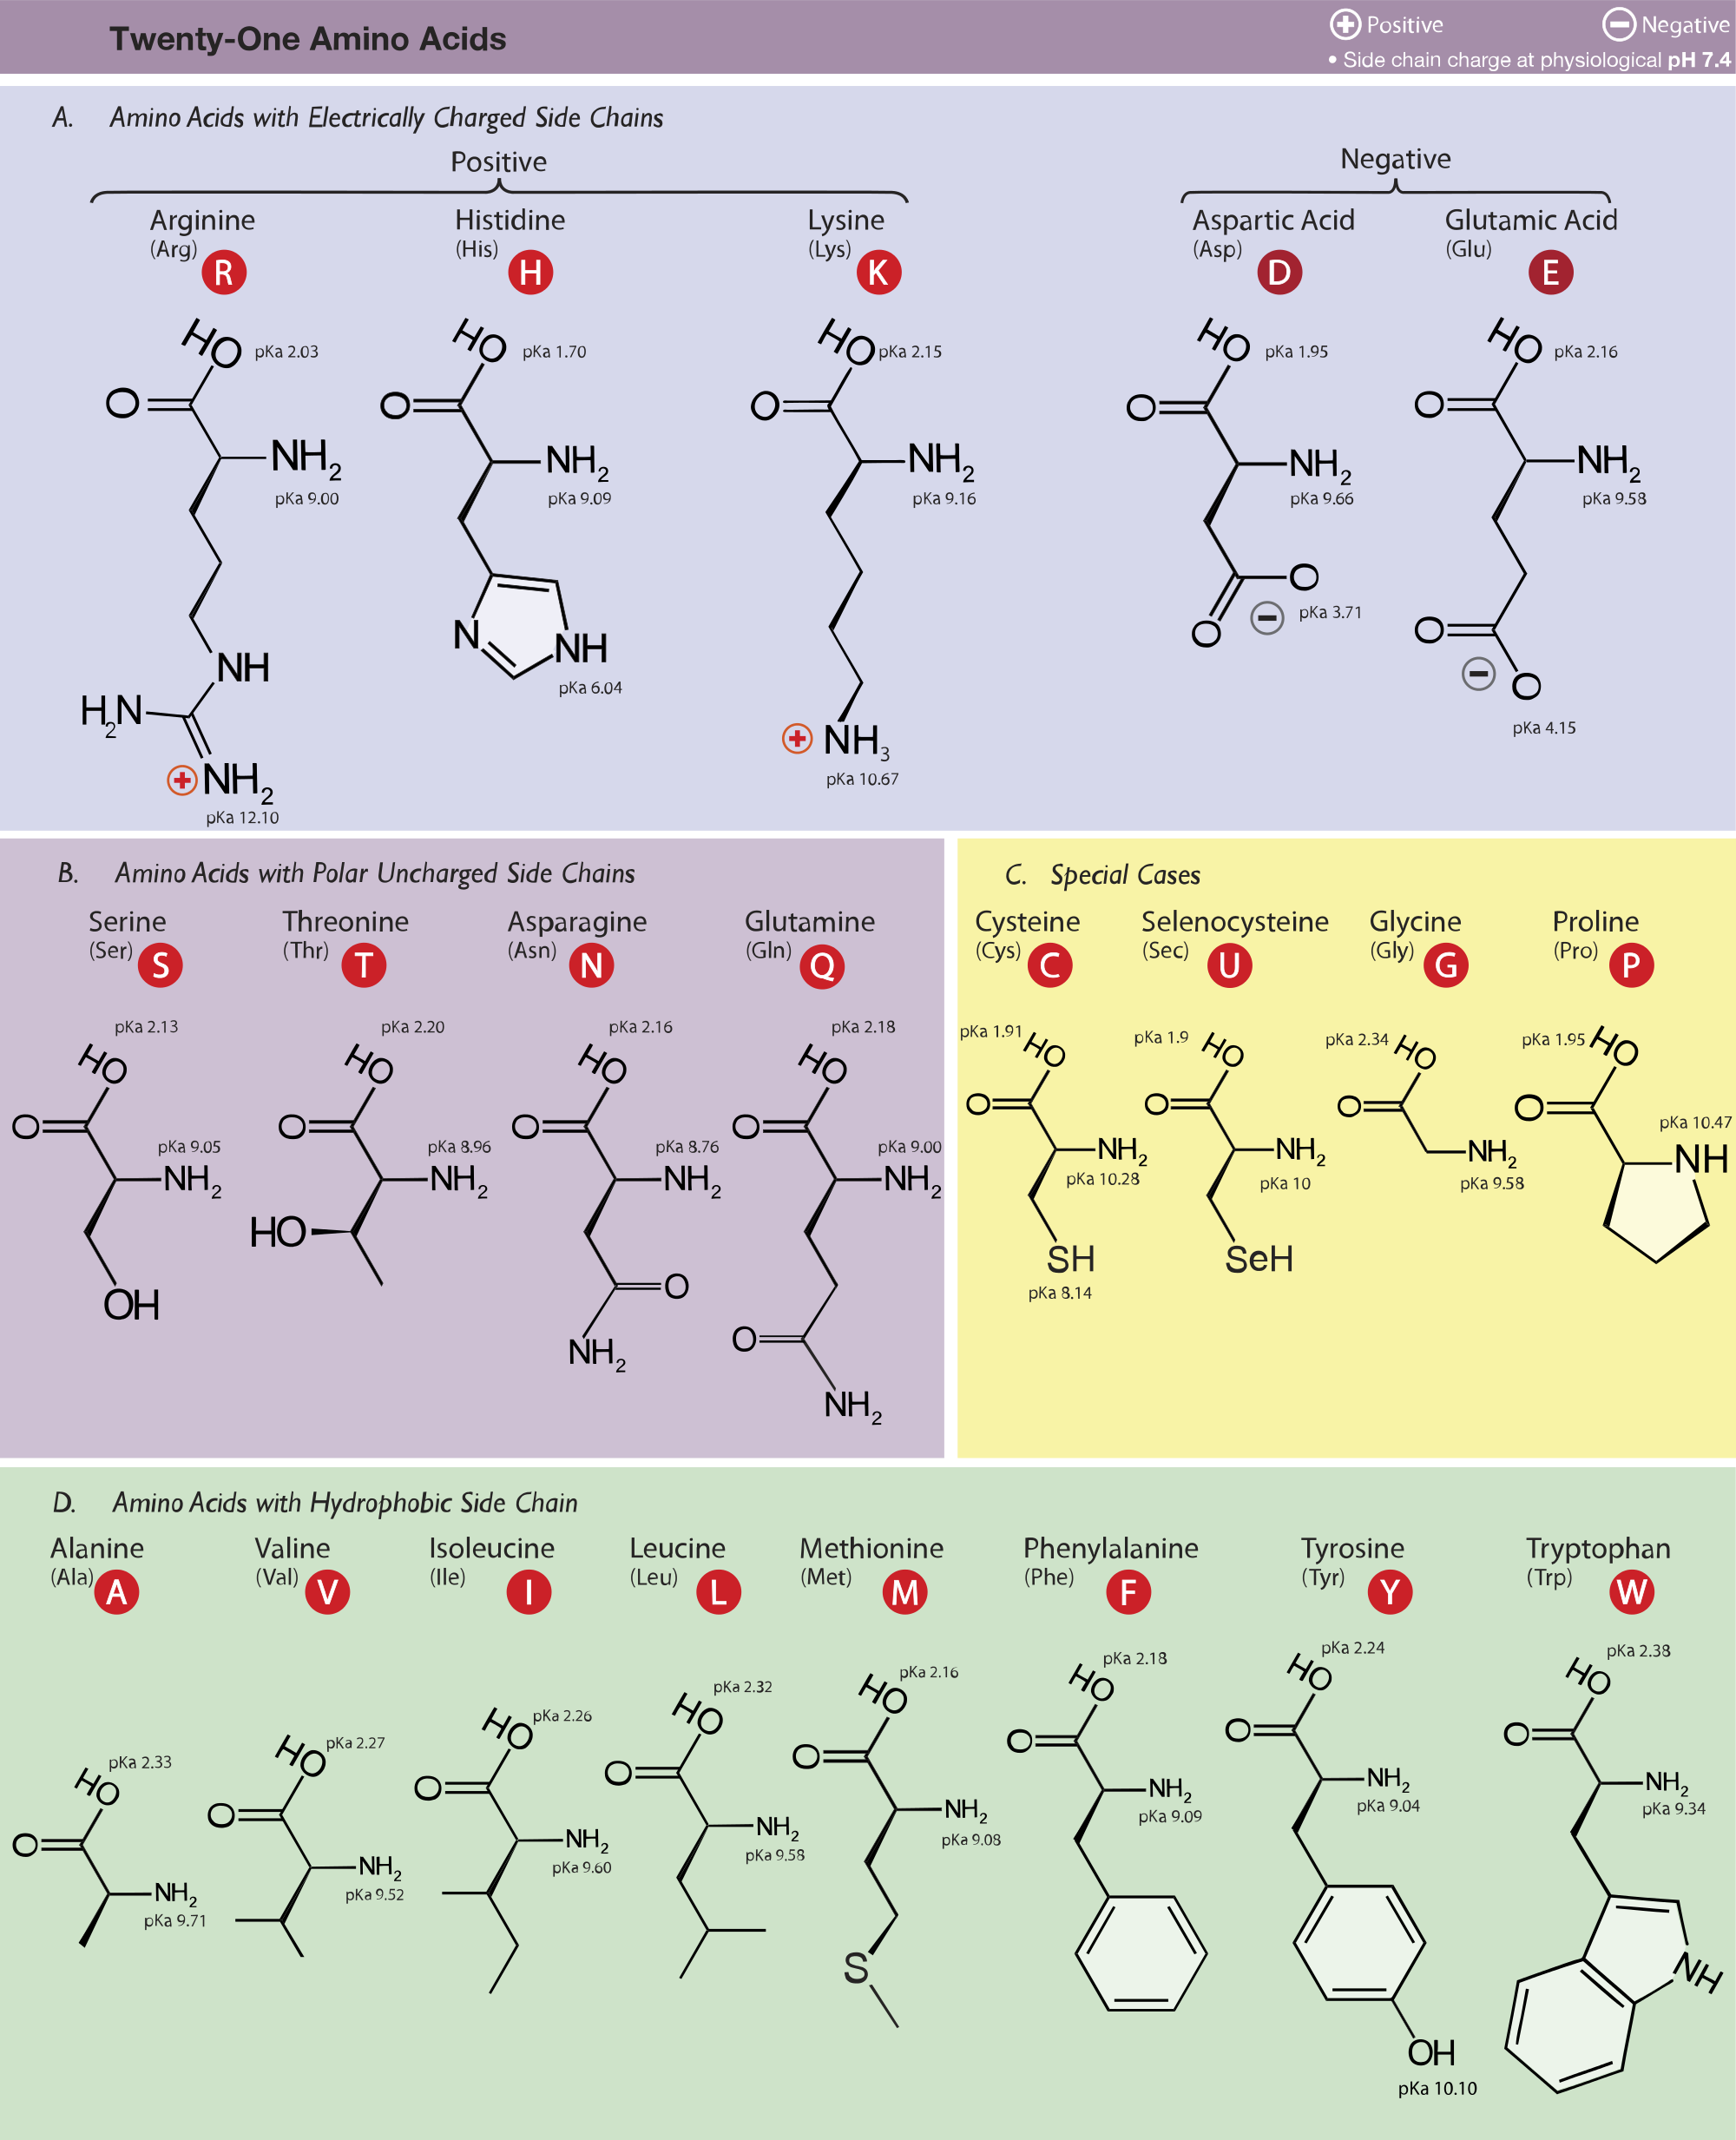

In [25]:
# APOE Protein Properties (ProtParam Analysis)
# Create a ProtParam object from the protein sequence
my_protein = ProtParam.ProteinAnalysis(str(protein_record.seq))

> [Analyzing protein sequences with the ProtParam module](https://biopython.org/wiki/ProtParam)


Amino acid composition

In [26]:
aa_names = {
    'A': ('Alanine', 'Ala'),
    'R': ('Arginine', 'Arg'),
    'N': ('Asparagine', 'Asn'),
    'D': ('Aspartic Acid', 'Asp'),
    'C': ('Cysteine', 'Cys'),
    'Q': ('Glutamine', 'Gln'),
    'E': ('Glutamic Acid', 'Glu'),
    'G': ('Glycine', 'Gly'),
    'H': ('Histidine', 'His'),
    'I': ('Isoleucine', 'Ile'),
    'L': ('Leucine', 'Leu'),
    'K': ('Lysine', 'Lys'),
    'M': ('Methionine', 'Met'),
    'F': ('Phenylalanine', 'Phe'),
    'P': ('Proline', 'Pro'),
    'S': ('Serine', 'Ser'),
    'T': ('Threonine', 'Thr'),
    'W': ('Tryptophan', 'Trp'),
    'Y': ('Tyrosine', 'Tyr'),
    'V': ('Valine', 'Val')
}

In [36]:
# Loop through the amino acids
for aa, count in sorted_aa[:20]:
    
    # Get the full name and three-letter code from the dictionary
    full_name, three_letter = aa_names[aa]
    
    # Calculate the percentage of this amino acid in the protein
    percentage = count / total_aa * 100
    

In [35]:
data = []
for aa, count in sorted_aa[:20]:
    full_name, three_letter = aa_names[aa]
    data.append([aa, three_letter, full_name, count, round(count / total_aa * 100, 2)])

df = pd.DataFrame(data, columns=['1-Letter', '3-Letter', 'Name', 'Count', '%'])
print(df)

   1-Letter 3-Letter           Name  Count      %
0         L      Leu        Leucine     41  12.93
1         E      Glu  Glutamic Acid     40  12.62
2         A      Ala        Alanine     39  12.30
3         R      Arg       Arginine     34  10.73
4         Q      Gln      Glutamine     32  10.09
5         V      Val         Valine     24   7.57
6         G      Gly        Glycine     18   5.68
7         S      Ser         Serine     14   4.42
8         K      Lys         Lysine     13   4.10
9         T      Thr      Threonine     12   3.79
10        D      Asp  Aspartic Acid     11   3.47
11        M      Met     Methionine      8   2.52
12        P      Pro        Proline      8   2.52
13        W      Trp     Tryptophan      8   2.52
14        F      Phe  Phenylalanine      4   1.26
15        Y      Tyr       Tyrosine      4   1.26
16        C      Cys       Cysteine      2   0.63
17        H      His      Histidine      2   0.63
18        I      Ile     Isoleucine      2   0.63


---

molecular_weight: Calculates the molecular weight of a protein.

In [13]:
# Molecular weight (Da)
mw = my_protein.molecular_weight()
print(f"Molecular weight: {mw:.2f} Da")

Molecular weight: 36153.66 Da


---

isoelectric_point: This method uses the module IsoelectricPoint to calculate the pI of a protein.

In [14]:
#Isoelectric point (pI)
pi = my_protein.isoelectric_point()
print(f"Isoelectric point (pI): {pi:.2f}")


Isoelectric point (pI): 5.65


---

instability_index: This method tests a protein for stability. Any value above 40 means the protein is unstable (=has a short half life).

In [15]:
#Instability index (below 40 = stable, above 40 = unstable)
instability = my_protein.instability_index()
print(f"Instability index: {instability:.2f}")
if instability < 40:
    print("Protein is predicted to be Stable.")
else:
    print("Protein is predicted to be Unstable.")

Instability index: 44.88
Protein is predicted to be Unstable.


---

aromaticity: The relative frequency of Phe+Trp+Tyr.

In [16]:
#Aromaticity (measure of aromatic amino acids)
aromaticity = my_protein.aromaticity()
print(f"Aromaticity: {aromaticity:.2f}")

Aromaticity: 0.05


- Phenylalanine = Phe = F = 4
- Tryptophan = Trp = W = 8
- Tyrosine = Tyr = Y = 4
> - F + W + Y = 4 + 8 + 4 = 16
> - Total a.a = 317
> - Aromaticity = 16/317 = 0.05

---

GRAVY (hydrophobicity):
- positive = hydrophobic
- negative = hydrophilic

In [17]:
gravy = my_protein.gravy()
print(f"GRAVY (hydrophobicity): {gravy:.2f}")
if gravy > 0:
    print("Hydrophobic protein")
else:
    print("Hydrophilic protein")


GRAVY (hydrophobicity): -0.60
Hydrophilic protein


---

Secondary Structure Fraction (Helix, Turn, Sheet)
Based on amino acid propensity:
- > Helix: V, I, Y, F, W, L
- > Turn:  N, P, G, S
- > Sheet: E, M, A, L


In [18]:
sec_structure = my_protein.secondary_structure_fraction ()
print(f"Helix fraction: {sec_structure[0]:.3f} ({sec_structure[0]*100:.1f}%)")
print(f"Turn fraction:  {sec_structure[1]:.3f} ({sec_structure[1]*100:.1f}%)")
print(f"Sheet fraction: {sec_structure[2]:.3f} ({sec_structure[2]*100:.1f}%)")


Helix fraction: 0.445 (44.5%)
Turn fraction:  0.164 (16.4%)
Sheet fraction: 0.300 (30.0%)


Secondary Structure Interpretation:

---

The 20 commonly occurring amino acids are abbreviated by using 20 letters
from the English alphabet (all letters except for B, J, O, U, X, and Z).
Protein strings are constructed from these 20 symbols.

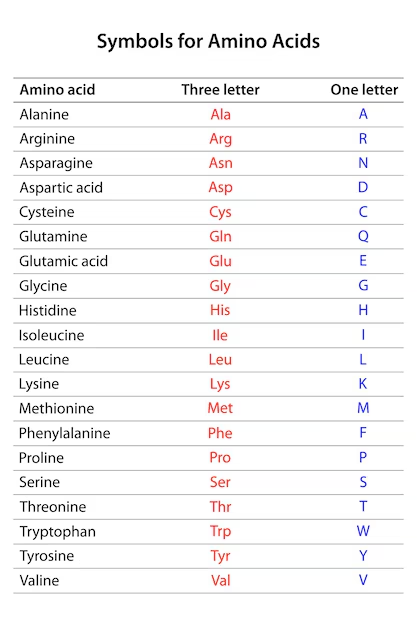

---

### ⭐ Interpretation





---

### ⭐ References 

- [NCBI](https://www.ncbi.nlm.nih.gov/)
- [Pandas Documentation](https://pandas.pydata.org/docs/index.html)
- [Accessing NCBI’s Entrez databases - biopython](https://biopython.org/docs/latest/Tutorial/chapter_entrez.html)
- [ClinVar](https://www.ncbi.nlm.nih.gov/clinvar/)
- [Analyzing protein sequences with the ProtParam module](https://biopython.org/wiki/ProtParam)

The APOE gene information was first explored manually using NCBI database.
Then the same Information was programmically retrieved using Biopython (ENTREZ API) to validate reproducibility.



https://en.wikipedia.org/wiki/GC-content